In [15]:
import subprocess, sys

subprocess.run([sys.executable, '-m', 'venv', r'C:\Users\bacus\tf_env'], capture_output=False)

pip = r'C:\Users\bacus\tf_env\Scripts\pip.exe'
subprocess.run([pip, 'install', 'tensorflow==2.17.0'], capture_output=False)
subprocess.run([pip, 'install', 'opencv-python', 'albumentations',
                'scikit-learn', 'matplotlib', 'seaborn', 'ipykernel'], capture_output=False)

print('Done!')

Done!


In [16]:
import subprocess
python = r'C:\Users\bacus\tf_env\Scripts\python.exe'
subprocess.run([python, '-m', 'ipykernel', 'install',
                '--user', '--name=tf_env', '--display-name=Python (tf_env)'],
               capture_output=False)
print('Kernel registered!')

Kernel registered!


In [17]:
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '1'

import numpy as np
import cv2
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger
)
import albumentations as A
from albumentations.core.composition import Compose
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

print('TF version :', tf.__version__)
print('Keras version:', keras.__version__)
print('GPUs        :', gpus)

TF version : 2.18.0
Keras version: 3.14.0
GPUs        : []


In [18]:
DATASET_ROOT_PATH = r'C:\Users\bacus\Documents\Cariex Dataset - Hanz'
IMG_SIZE    = 256
BATCH_SIZE  = 8
MODEL_NAME  = 'cariex_classifier'

CARIES_CLASSES = ['healthy', 'moderate_caries', 'deep_caries']
NUM_CLASSES    = len(CARIES_CLASSES)

print(f'Classes    : {CARIES_CLASSES}')
print(f'Num classes: {NUM_CLASSES}')

Classes    : ['healthy', 'moderate_caries', 'deep_caries']
Num classes: 3


In [19]:
# Cell 5 — Augmentation
train_transforms = Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Rotate(limit=20, p=0.6),
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.5),
    A.GaussianBlur(blur_limit=(3, 7), p=0.3),
    A.CLAHE(clip_limit=3.0, p=0.3),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=10, p=0.3),
    A.GridDistortion(p=0.2),
    A.CoarseDropout(max_holes=8, max_height=24, max_width=24, p=0.3),
])

val_transforms = Compose([])

C:\Users\bacus\AppData\Local\Temp\ipykernel_21440\2159687409.py:11: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=24, max_width=24, p=0.3),


In [20]:
def scan_dataset(root):
    root = Path(root)
    paths, labels = [], []

    for idx, name in enumerate(CARIES_CLASSES):
        folder = root / name
        if not folder.exists():
            print(f'  Warning: not found — {folder}')
            continue
        for p in folder.iterdir():
            if p.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp'}:
                paths.append(str(p))
                labels.append(idx)

    print(f'\nTotal images scanned: {len(paths)}')
    for i, name in enumerate(CARIES_CLASSES):
        print(f'  [{i}] {name}: {labels.count(i)}')
    return paths, labels

all_paths, all_labels = scan_dataset(DATASET_ROOT_PATH)


Total images scanned: 1188
  [0] healthy: 431
  [1] moderate_caries: 332
  [2] deep_caries: 425


In [21]:
train_paths, val_paths, train_labels, val_labels = train_test_split(
    all_paths, all_labels,
    test_size=0.2,
    random_state=42,
    stratify=all_labels
)
print(f'Train: {len(train_paths)}  |  Val: {len(val_paths)}')

Train: 950  |  Val: 238


In [22]:
# Cell 8 — Image Loader (confirmed correct)
def load_image(img_path, transforms=None):
    img = cv2.imread(str(img_path))
    if img is None:
        raise ValueError(f'Failed to load: {img_path}')
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    if transforms:
        img = transforms(image=img)['image']
    return img.astype(np.float32)  # ✅ stays in [0, 255] — model preprocesses internally

In [23]:

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=train_labels
)
class_weight_dict = dict(enumerate(class_weights_array))
print('Class weights:', {CARIES_CLASSES[k]: round(v, 3) for k, v in class_weight_dict.items()})

train_sample_weights = np.array(
    [class_weight_dict[l] for l in train_labels], dtype=np.float32
)

Class weights: {'healthy': 0.918, 'moderate_caries': 1.195, 'deep_caries': 0.931}


In [24]:
def create_dataset(paths, labels, transforms=None, sample_weights=None, shuffle=True):
    images, valid_labels, valid_weights = [], [], []

    for i, (p, l) in enumerate(zip(paths, labels)):
        try:
            img = load_image(p, transforms)
            images.append(img)
            valid_labels.append(l)
            if sample_weights is not None:
                valid_weights.append(sample_weights[i])
        except Exception as e:
            print(f'  Skipping {p}: {e}')

    images    = np.array(images, dtype=np.float32)
    labels_oh = keras.utils.to_categorical(valid_labels, num_classes=NUM_CLASSES)
    print(f'  Loaded {len(images)} images | shape: {images.shape}')

    if sample_weights is not None:
        valid_weights = np.array(valid_weights, dtype=np.float32)
        ds = tf.data.Dataset.from_tensor_slices((images, labels_oh, valid_weights))
    else:
        ds = tf.data.Dataset.from_tensor_slices((images, labels_oh))

    if shuffle:
        ds = ds.shuffle(min(1000, len(images)), reshuffle_each_iteration=True)

    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds, len(images), valid_labels

print('Loading train dataset...')
train_dataset, train_count, train_labels_loaded = create_dataset(
    train_paths, train_labels,
    transforms=train_transforms,
    sample_weights=train_sample_weights,
    shuffle=True
)

print('Loading val dataset...')
val_dataset, val_count, val_labels_loaded = create_dataset(
    val_paths, val_labels,
    transforms=val_transforms,
    sample_weights=None,
    shuffle=False    # FIX: never shuffle val
)

print(f'\nTrain: {train_count}  |  Val: {val_count}')

Loading train dataset...
  Loaded 950 images | shape: (950, 256, 256, 3)
Loading val dataset...
  Loaded 238 images | shape: (238, 256, 256, 3)

Train: 950  |  Val: 238


In [25]:
def build_classifier(input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    base_model = keras.applications.EfficientNetB3(
        input_shape=input_shape,
        weights='imagenet',
        include_top=False
    )
    base_model.trainable = False

    inputs = keras.Input(shape=input_shape)
    x = keras.applications.efficientnet.preprocess_input(inputs)
    x = base_model(x, training=False)
    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Dense(512, activation='relu',
            kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = Dropout(0.6)(x)
    x = keras.layers.Dense(256, activation='relu',
            kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = Dropout(0.5)(x)
    outputs = keras.layers.Dense(NUM_CLASSES, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name='CariexClassifier')
    return model, base_model

# ✅ THIS LINE WAS MISSING — actually call the function
model, base_model = build_classifier()
model.summary()

Model: "CariexClassifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 8, 8, 1536)     │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       786,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,708,722 (44.67 MB)

 Trainable params: 922,115 (3.52 MB)

 Non-trainable params: 10,786,607 (41.15 MB)

In [26]:
output_dir = Path(f'trained_models/{MODEL_NAME}')
output_dir.mkdir(parents=True, exist_ok=True)
print(f'Saving to: {output_dir}')

Saving to: trained_models\cariex_classifier


In [27]:
print('--- Phase 1: Training head only ---')

# Phase 1 — more epochs, slightly lower initial LR to reduce overfit speed
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4),  # ✅ lowered from 1e-3
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

callbacks_p1 = [
    ModelCheckpoint(str(output_dir / 'best_model.keras'),
                    monitor='val_auc',        # ✅ monitor AUC — more robust than accuracy
                    mode='max', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_auc', patience=8,
                  mode='max', restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, mode='min', min_lr=1e-6, verbose=1),
    CSVLogger(str(output_dir / 'phase1_log.csv')),
]

history1 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,           # ✅ more room for LR to decay
    callbacks=callbacks_p1,
    verbose=1
)

--- Phase 1: Training head only ---
Epoch 1/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.4349 - auc: 0.6323 - loss: 1.8175
Epoch 1: val_auc improved from None to 0.79796, saving model to trained_models\cariex_classifier\best_model.keras

Epoch 1: finished saving model to trained_models\cariex_classifier\best_model.keras
119/119 ━━━━━━━━━━━━━━━━━━━━ 54s 318ms/step - accuracy: 0.4758 - auc: 0.6657 - loss: 1.7157 - val_accuracy: 0.6303 - val_auc: 0.7980 - val_loss: 0.9599 - learning_rate: 5.0000e-04
Epoch 2/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.5206 - auc: 0.7233 - loss: 1.4674
Epoch 2: val_auc improved from 0.79796 to 0.80947, saving model to trained_models\cariex_classifier\best_model.keras

Epoch 2: finished saving model to trained_models\cariex_classifier\best_model.keras
119/119 ━━━━━━━━━━━━━━━━━━━━ 35s 291ms/step - accuracy: 0.5305 - auc: 0.7258 - loss: 1.4286 - val_accuracy: 0.6387 - val_auc: 0.8095 - val_loss: 0.9333 - learning_rate: 5.0000e-04

In [28]:
print('--- Phase 2: Fine-tuning top layers ---')

base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

for layer in base_model.layers:
    if isinstance(layer, keras.layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),  
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

callbacks_p2 = [
    ModelCheckpoint(str(output_dir / 'best_model.keras'),
                    monitor='val_auc',         
                    mode='max', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_auc', patience=10,
                  mode='max', restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=4, mode='min', min_lr=1e-8, verbose=1),
    CSVLogger(str(output_dir / 'phase2_log.csv')),
]

history2 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=40,
    callbacks=callbacks_p2,
    verbose=1
)

--- Phase 2: Fine-tuning top layers ---
Epoch 1/40
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - accuracy: 0.7237 - auc: 0.8783 - loss: 0.8036
Epoch 1: val_auc improved from None to 0.82981, saving model to trained_models\cariex_classifier\best_model.keras

Epoch 1: finished saving model to trained_models\cariex_classifier\best_model.keras
119/119 ━━━━━━━━━━━━━━━━━━━━ 65s 449ms/step - accuracy: 0.7063 - auc: 0.8744 - loss: 0.8058 - val_accuracy: 0.6807 - val_auc: 0.8298 - val_loss: 0.8972 - learning_rate: 1.0000e-05
Epoch 2/40
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step - accuracy: 0.7560 - auc: 0.8950 - loss: 0.7497
Epoch 2: val_auc improved from 0.82981 to 0.83068, saving model to trained_models\cariex_classifier\best_model.keras

Epoch 2: finished saving model to trained_models\cariex_classifier\best_model.keras
119/119 ━━━━━━━━━━━━━━━━━━━━ 46s 387ms/step - accuracy: 0.7326 - auc: 0.8826 - loss: 0.7843 - val_accuracy: 0.6723 - val_auc: 0.8307 - val_loss: 0.8941 - learning_rate: 1.0000

In [29]:
# Cell 15 — Evaluate Best Model
best_model = keras.models.load_model(str(output_dir / 'best_model.keras'))
results = best_model.evaluate(val_dataset, verbose=1)
print(f'\nVal Loss: {results[0]:.4f} | Val Accuracy: {results[1]:.4f} | Val AUC: {results[2]:.4f}')

30/30 ━━━━━━━━━━━━━━━━━━━━ 12s 249ms/step - accuracy: 0.6723 - auc: 0.8307 - loss: 0.8941

Val Loss: 0.8941 | Val Accuracy: 0.6723 | Val AUC: 0.8307


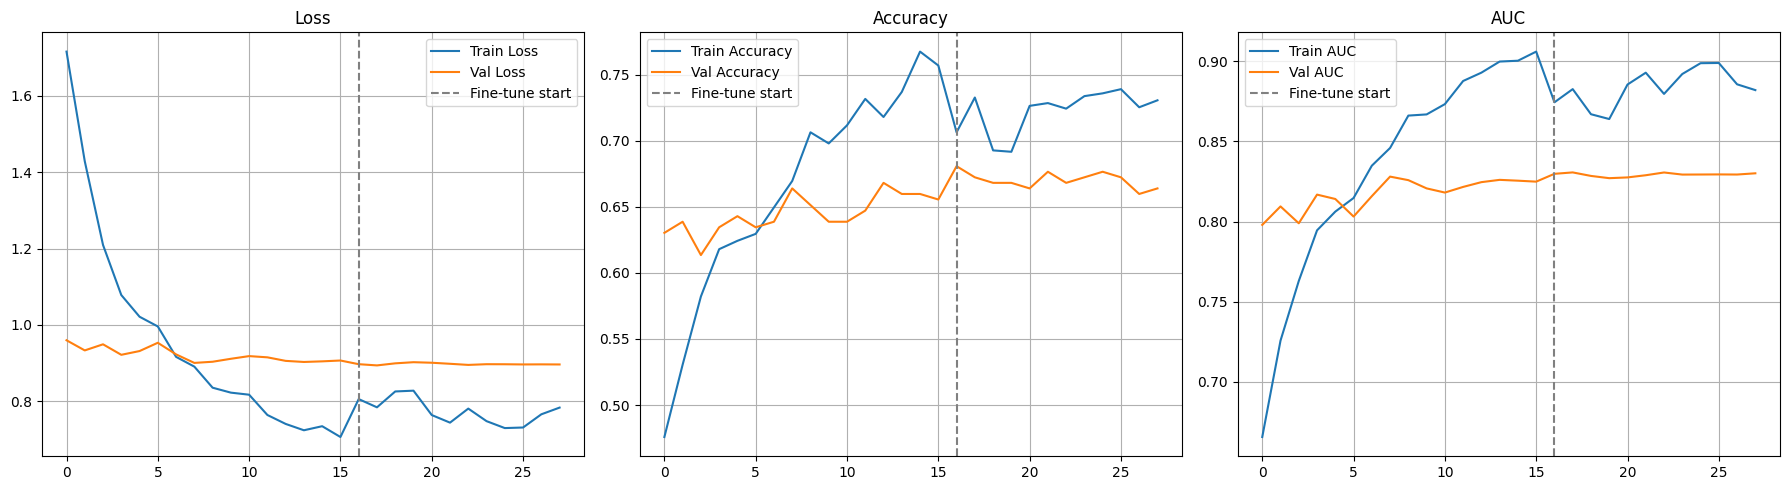

In [30]:
# Cell 16 — Training Curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

def combine(h1, h2, key):
    return h1.history.get(key, []) + h2.history.get(key, [])

p1_len = len(history1.history['loss'])

for ax, (train_key, val_key, title) in zip(axes, [
    ('loss',     'val_loss',     'Loss'),
    ('accuracy', 'val_accuracy', 'Accuracy'),
    ('auc',      'val_auc',      'AUC'),
]):
    ax.plot(combine(history1, history2, train_key), label=f'Train {title}')
    ax.plot(combine(history1, history2, val_key),   label=f'Val {title}')
    ax.axvline(p1_len, color='gray', linestyle='--', label='Fine-tune start')
    ax.set_title(title); ax.legend(); ax.grid(True)

plt.tight_layout()
plt.savefig(str(output_dir / 'training_curves.png'), dpi=150)
plt.show()

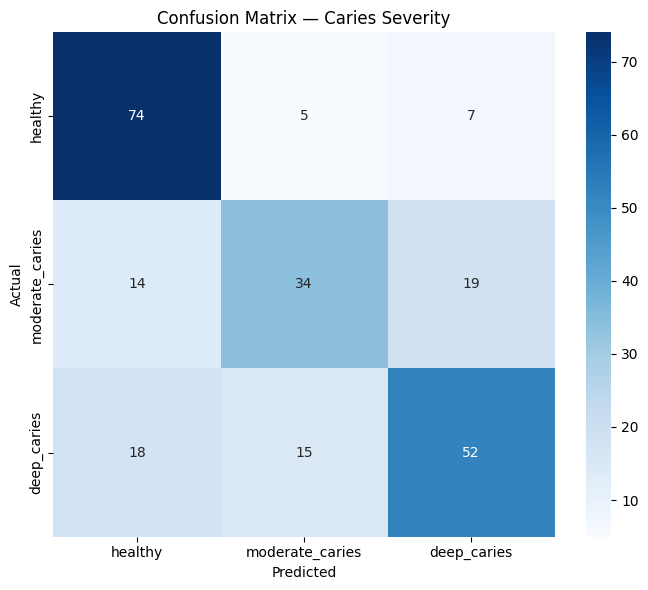


Classification Report:
                 precision    recall  f1-score   support

        healthy       0.70      0.86      0.77        86
moderate_caries       0.63      0.51      0.56        67
    deep_caries       0.67      0.61      0.64        85

       accuracy                           0.67       238
      macro avg       0.66      0.66      0.66       238
   weighted avg       0.67      0.67      0.66       238



In [31]:
# Cell 17 — Confusion Matrix & Classification Report
y_true, y_pred = [], []

for batch in val_dataset:
    imgs, lbls = batch[0], batch[1]
    preds = best_model.predict(imgs, verbose=0)
    y_true.extend(np.argmax(lbls.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CARIES_CLASSES,
            yticklabels=CARIES_CLASSES)
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('Confusion Matrix — Caries Severity')
plt.tight_layout()
plt.savefig(str(output_dir / 'confusion_matrix.png'), dpi=150)
plt.show()

print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=CARIES_CLASSES))

In [32]:
# Cell 18 — Build U-Net
# WARNING: Uses SYNTHETIC masks — replace create_synthetic_masks() with real annotations!

def build_unet(input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    def conv_block(x, filters):
        x = keras.layers.Conv2D(filters, 3, activation='relu', padding='same')(x)
        x = keras.layers.BatchNormalization()(x)
        x = keras.layers.Conv2D(filters, 3, activation='relu', padding='same')(x)
        x = keras.layers.BatchNormalization()(x)
        return x

    inputs = keras.Input(shape=input_shape)
    c1 = conv_block(inputs, 32);  p1 = keras.layers.MaxPooling2D(2)(c1)
    c2 = conv_block(p1,     64);  p2 = keras.layers.MaxPooling2D(2)(c2)
    c3 = conv_block(p2,    128);  p3 = keras.layers.MaxPooling2D(2)(c3)
    c4 = conv_block(p3,    256)

    u5 = keras.layers.UpSampling2D(2)(c4)
    u5 = keras.layers.concatenate([u5, c3])
    c5 = conv_block(u5, 128)

    u6 = keras.layers.UpSampling2D(2)(c5)
    u6 = keras.layers.concatenate([u6, c2])
    c6 = conv_block(u6, 64)

    u7 = keras.layers.UpSampling2D(2)(c6)
    u7 = keras.layers.concatenate([u7, c1])
    c7 = conv_block(u7, 32)

    outputs = keras.layers.Conv2D(1, 1, activation='sigmoid')(c7)
    return keras.Model(inputs, outputs, name='UNet')

unet_model = build_unet()
unet_model.summary()

# FIX: keras.metrics.Dice not in TF 2.17 → use BinaryIoU
unet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.BinaryIoU(name='iou')]
)

Model: "UNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        896 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    147,584 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_2[

 Total params: 1,952,513 (7.45 MB)

 Trainable params: 1,949,697 (7.44 MB)

 Non-trainable params: 2,816 (11.00 KB)

In [33]:
# Cell 19 — Prepare Segmentation Dataset
def create_synthetic_masks(images, labels):
    """⚠ SYNTHETIC masks only — replace with real annotated masks for actual training."""
    masks = np.zeros((len(images), IMG_SIZE, IMG_SIZE, 1), dtype=np.float32)
    for i, label in enumerate(labels):
        if label > 0:
            cx = np.random.randint(60, IMG_SIZE - 60)
            cy = np.random.randint(60, IMG_SIZE - 60)
            radius = 20 + label * 12
            yy, xx = np.ogrid[:IMG_SIZE, :IMG_SIZE]
            masks[i, (xx - cx)**2 + (yy - cy)**2 <= radius**2, 0] = 1.0
    return masks

seg_images, seg_labels_list = [], []
for p, l in zip(train_paths, train_labels):
    try:
        img = load_image(p, train_transforms)
        seg_images.append(img)
        seg_labels_list.append(l)
    except:
        pass

seg_images    = np.array(seg_images, dtype=np.float32)
seg_labels_arr = np.array(seg_labels_list)
seg_masks     = create_synthetic_masks(seg_images, seg_labels_arr)
print(f'Seg images: {seg_images.shape} | Masks: {seg_masks.shape}')

# FIX: added val split for U-Net
seg_img_train, seg_img_val, seg_mask_train, seg_mask_val = train_test_split(
    seg_images, seg_masks, test_size=0.15, random_state=42
)

seg_train_ds = (tf.data.Dataset.from_tensor_slices((seg_img_train, seg_mask_train))
                .shuffle(500).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))
seg_val_ds   = (tf.data.Dataset.from_tensor_slices((seg_img_val, seg_mask_val))
                .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE))

Seg images: (950, 256, 256, 3) | Masks: (950, 256, 256, 1)


In [ ]:
# Cell 20 — Train U-Net
unet_output_dir = Path('trained_models/unet_segmentation')
unet_output_dir.mkdir(parents=True, exist_ok=True)

unet_callbacks = [
    ModelCheckpoint(str(unet_output_dir / 'best_unet.keras'),
                    monitor='val_loss', mode='min',
                    save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_loss', patience=7,
                  mode='min', restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, mode='min', min_lr=1e-7, verbose=1),
    CSVLogger(str(unet_output_dir / 'segmentation_log.csv')),
]

print('Training U-Net...')
unet_history = unet_model.fit(
    seg_train_ds,
    validation_data=seg_val_ds,  
    epochs=20,
    callbacks=unet_callbacks,
    verbose=1
)
print('U-Net training complete!')

Training U-Net...
Epoch 1/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5309 - iou: 0.2856 - loss: 0.7228
Epoch 1: val_loss improved from None to 0.71572, saving model to trained_models\unet_segmentation\best_unet.keras

Epoch 1: finished saving model to trained_models\unet_segmentation\best_unet.keras
101/101 ━━━━━━━━━━━━━━━━━━━━ 288s 3s/step - accuracy: 0.5656 - iou: 0.3052 - loss: 0.6937 - val_accuracy: 0.5180 - val_iou: 0.2800 - val_loss: 0.7157 - learning_rate: 1.0000e-04
Epoch 2/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6837 - iou: 0.3734 - loss: 0.6540
Epoch 2: val_loss improved from 0.71572 to 0.63152, saving model to trained_models\unet_segmentation\best_unet.keras

Epoch 2: finished saving model to trained_models\unet_segmentation\best_unet.keras
101/101 ━━━━━━━━━━━━━━━━━━━━ 241s 2s/step - accuracy: 0.7190 - iou: 0.3908 - loss: 0.6459 - val_accuracy: 0.7921 - val_iou: 0.4377 - val_loss: 0.6315 - learning_rate: 1.0000e-04
Epoch 3/20
101/101 ━━━━━━━━━━

In [ ]:
# Cell 21 — Visualize U-Net Predictions
best_unet = keras.models.load_model(str(unet_output_dir / 'best_unet.keras'))

sample_idx   = np.random.choice(len(seg_img_val), min(5, len(seg_img_val)), replace=False)
sample_imgs  = seg_img_val[sample_idx]
sample_masks_vis = seg_mask_val[sample_idx]
predictions  = best_unet.predict(sample_imgs, verbose=0)

fig, axes = plt.subplots(len(sample_idx), 3, figsize=(12, 4 * len(sample_idx)))

for i in range(len(sample_idx)):
    axes[i, 0].imshow(sample_imgs[i].astype(np.uint8));         axes[i, 0].set_title('Original');    axes[i, 0].axis('off')
    axes[i, 1].imshow(sample_masks_vis[i].squeeze(), cmap='gray'); axes[i, 1].set_title('GT Mask');  axes[i, 1].axis('off')
    axes[i, 2].imshow(predictions[i].squeeze(), cmap='gray');   axes[i, 2].set_title('Predicted');   axes[i, 2].axis('off')

plt.tight_layout()
plt.savefig(str(unet_output_dir / 'segmentation_predictions.png'), dpi=150)
plt.show()

print('\nAll done! Models saved to trained_models/')